In [53]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [54]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

import shap
shap.initjs()

In [56]:
data = pd.read_csv(r"C:\Users\user\Downloads\abalone.csv")
data.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


Text(0, 0.5, 'Whole weight')

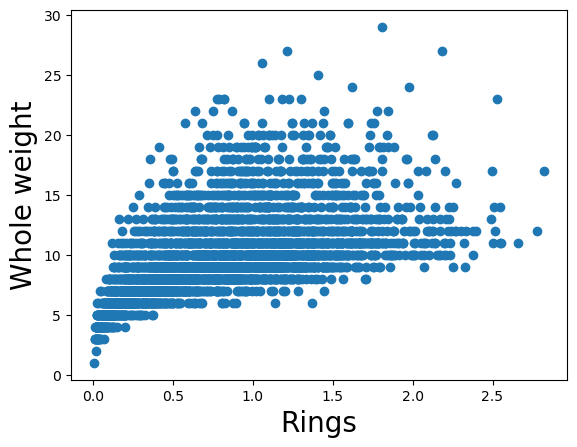

In [57]:
plt.scatter(data['Whole weight'], data['Rings'])
plt.xlabel('Rings', size=20)
plt.ylabel('Whole weight', size=20)

Text(0.5, 0, 'age')

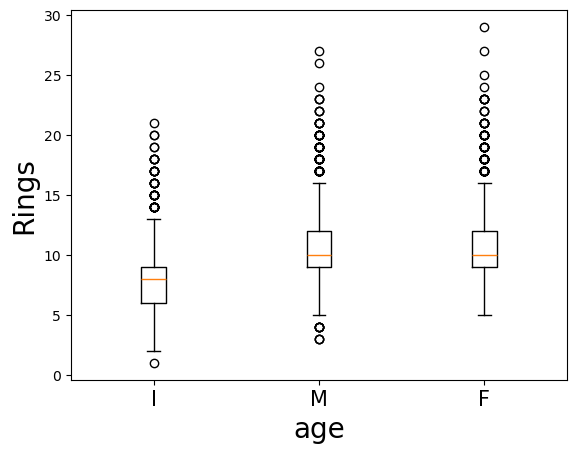

In [58]:
plt.boxplot(data[data.Sex=='I']['Rings'],positions=[1])
plt.boxplot(data[data.Sex=='M']['Rings'],positions=[2])
plt.boxplot(data[data.Sex=='F']['Rings'],positions=[3])

plt.xticks(ticks=[1,2,3], labels=['I', 'M', 'F'], size=15)
plt.ylabel('Rings', size=20)
plt.xlabel('age', size=20)

<Axes: >

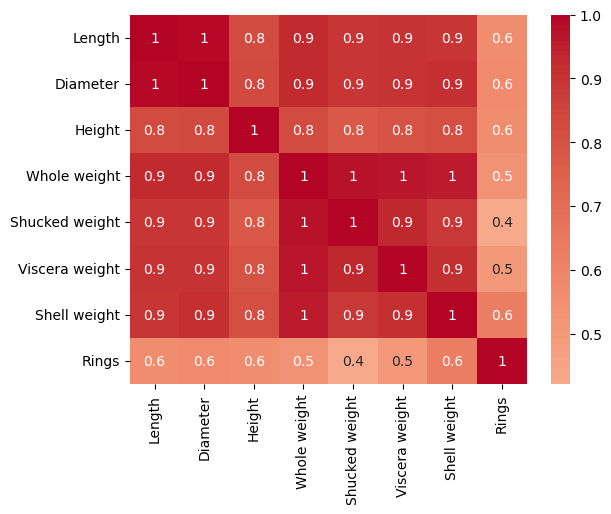

In [59]:
con = ['Length',	'Diameter',	'Height',	'Whole weight',	'Shucked weight',	'Viscera weight', 'Shell weight',	'Rings']
corr_matrix = pd.DataFrame(data[con], columns=con).corr()

sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt='.1g')
            
            

In [60]:
df = pd.get_dummies(data, dtype='int')

In [61]:
df.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Sex_F,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,0,0,1
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0,0,1
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,1,0,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,0,0,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,0,1,0


In [62]:
X = df.drop(columns=['Rings',  'Whole weight', 'Diameter' ])

In [63]:
X.head()

,Length,Height,Shucked weight,Viscera weight,Shell weight,Sex_F,Sex_I,Sex_M
0,0.455,0.095,0.2245,0.1010,0.150,0,0,1
1,0.350,0.090,0.0995,0.0485,0.070,0,0,1
2,0.530,0.135,0.2565,0.1415,0.210,1,0,0
3,0.440,0.125,0.2155,0.1140,0.155,0,0,1
4,0.330,0.080,0.0895,0.0395,0.055,0,1,0


In [64]:
y = df.Rings

In [65]:
y.head()

0    15
1     7
2     9
3    10
4     7
Name: Rings, dtype: int64

In [66]:
model = xgb.XGBRegressor(objective='reg:squarederror')
model.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Text(0.5, 0, 'actaual')

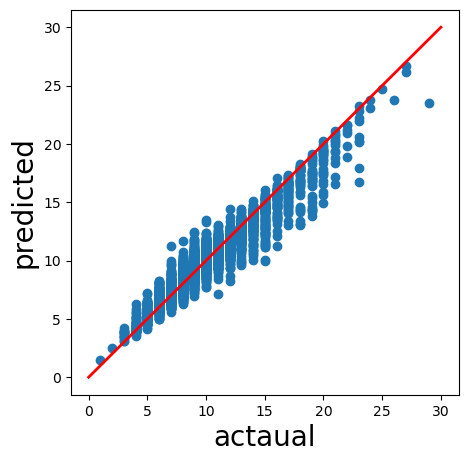

In [67]:
y_pred = model.predict(X)
plt.figure(figsize=(5,5))
plt.scatter(y,y_pred)
plt.plot([0,30],
         [0,30],
         color='r',
         linestyle='-',
         linewidth=2)
plt.ylabel('predicted', size=20)
plt.xlabel('actaual', size=20)

           

In [68]:
explainer = shap.Explainer(model)
shap_values = explainer(X)

In [69]:
np.shape(shap_values.values)

(4177, 8)

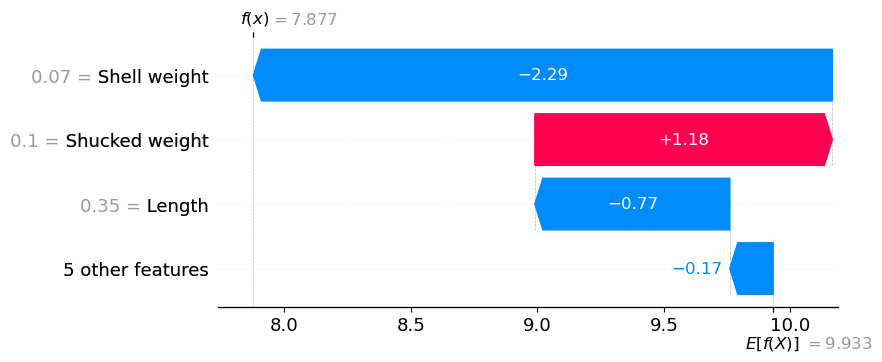

In [70]:
shap.plots.waterfall(shap_values[1], max_display=4)

In [71]:
shap.plots.force(shap_values[0:100])

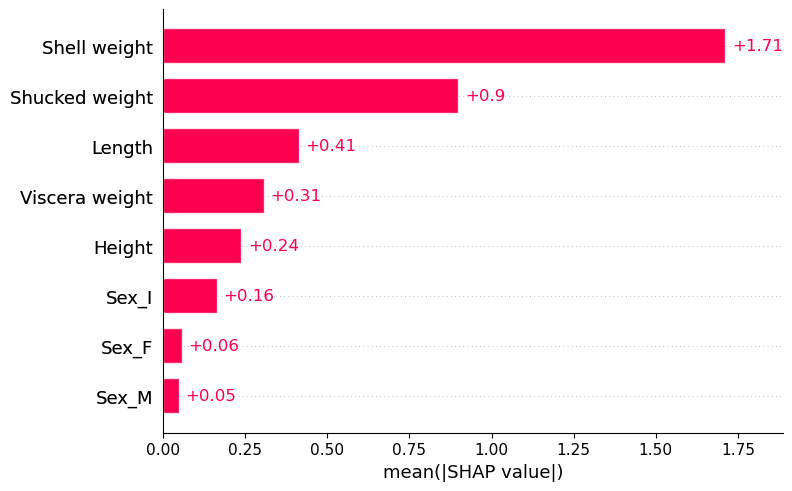

In [72]:
shap.plots.bar(shap_values)

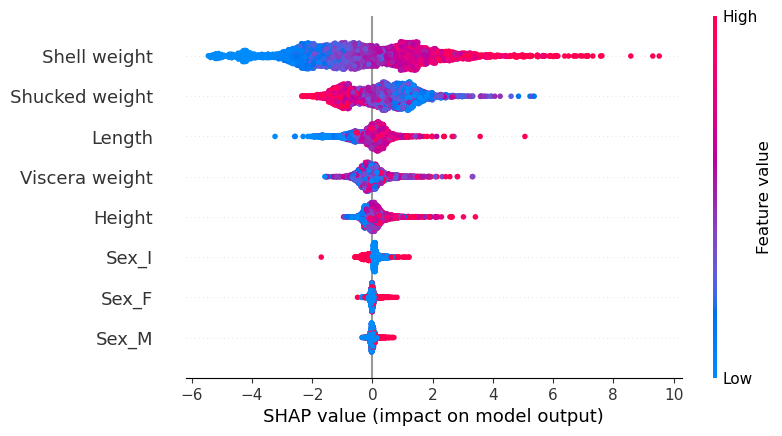

In [73]:
shap.plots.beeswarm(shap_values)

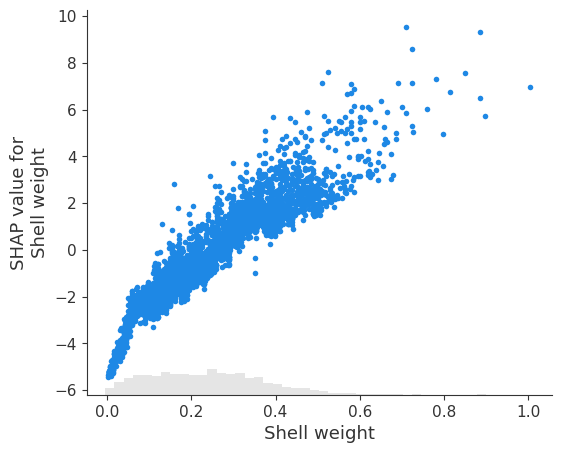

In [74]:
shap.plots.scatter(shap_values[:,'Shell weight'])

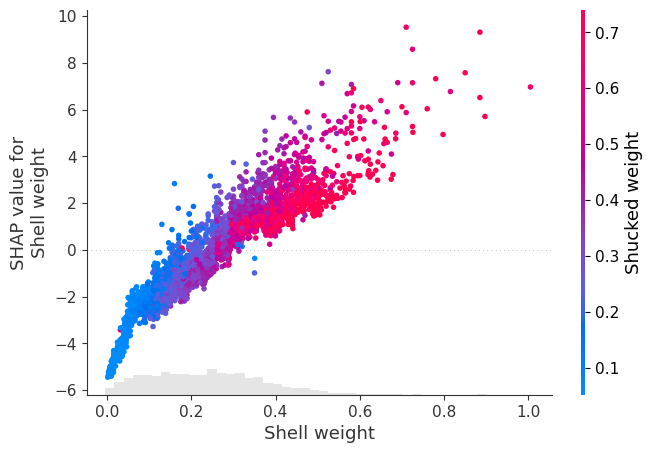

In [75]:
shap.plots.scatter(shap_values[:,'Shell weight'],
                   color=shap_values[:,'Shucked weight'])

In [76]:
from lime import lime_tabular
import numpy as np

explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X),
    feature_names=X.columns,
    mode='regression'
)
                                              

C:\Users\user\anaconda3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\user\anaconda3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\user\anaconda3\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use

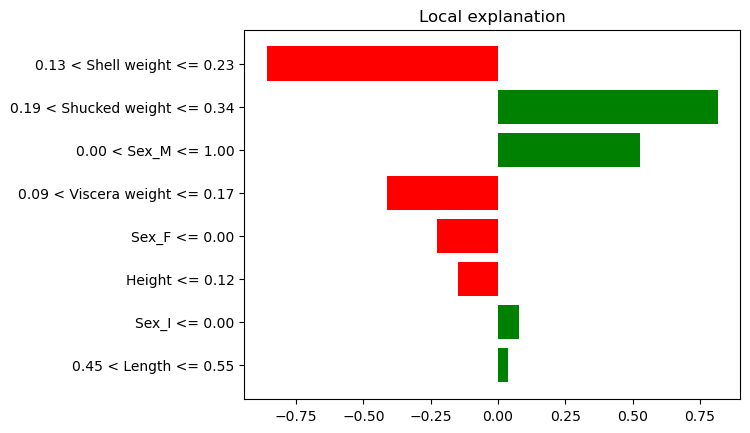

In [77]:
# Import necessary display functions explicitly
from IPython.display import display, HTML
import IPython

# Create the explanation instance
exp = explainer.explain_instance(
    X.iloc[0],
    model.predict,
    num_features=len(X.columns)
)

# Alternative approach to display the explanation
# Method 1: Use the explicit display import
try:
    exp.show_in_notebook(show_table=True)
except ImportError:
    # Method 2: If show_in_notebook fails, use as_pyplot_figure or save_to_file
    fig = exp.as_pyplot_figure()
    fig.show()
    
    # Method 3: Or display as HTML
    # display(HTML(exp.as_html()))

In [78]:
from sklearn.inspection import PartialDependenceDisplay

C:\Users\user\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 5 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 6 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: Futur

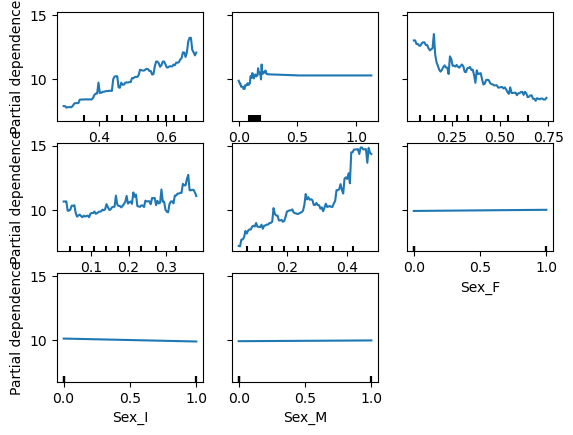

In [79]:
PartialDependenceDisplay.from_estimator(
                                        model,
                                        X,
                                        features=['Length',	'Height',	'Shucked weight',	'Viscera weight',	'Shell weight',	'Sex_F',	'Sex_I',	'Sex_M']
)

plt.show()